---
title: "# 政策案例实验：从四个均值到 DID {.unnumbered}"
---

本实验使用**模拟数据**。政策背景来自绿色金融改革创新试验区，但城市编号、企业和融资成本全部由代码生成，不代表湖州、衢州或任何真实企业。

目标是看懂：只比较政策前后为什么不够；加入对照组后系数在算什么；复杂模型为什么仍需识别假设。

[回到第一讲](../../lectures/intro.qmd#sec-intro-policy) · [下载本 Notebook](https://raw.githubusercontent.com/lianxhcn/FinEco/main/notebooks/intro/policy-stata.ipynb)

真实政策的效果未知，不便直接检验一个计算步骤是否恢复了正确答案。模拟允许我们先写入已知效果，再检查手算和回归是否接近它；这能帮助理解计算，但不能替代真实研究的识别论证。

本页按“生成面板—手算变化差—回归核对—改变一个条件”展开。第一次运行请先按[使用指南](../../getting-started.qmd)获取完整资料并完成环境检查。

## 1. 建立可复现的教学面板

设置 40 个城市、每城 20 家企业、2013—2022 年共 10 年。前 20 个城市在 2018 年开始处理；样本大小和分组仅服务教学。真实试点若只有少数处理地区，不能照搬这里的显著性推断。

生成过程中明确写入企业差异、共同年份变化和 -0.4 个百分点的处理效应。随机种子固定，所以从头运行可得到同一份数据。

面板中的每一行是“某企业、某一年”。同一企业有 10 行，企业编号与年份一起必须唯一，代码 `isid firm_id year` 就检查这个条件。处理标记 `treat` 区分城市组别，`post` 区分政策前后，`did` 是二者乘积。

生成 `cost` 时，各部分的作用是：

- `6` 设定基准成本水平，`0.3*treat` 让处理组初始水平较高。
- `firm_effect` 是不随年份变化的企业差异，用均值 0、标准差 0.25 的正态随机数生成。
- `-0.08*(year-2013)` 让两组每年都下降 0.08 个百分点，表示共同时间趋势。
- `-0.4*did` 只在处理组进入政策后生效；最后的正态随机扰动均值为 0、标准差为 0.3。

这些常数都服务于教学，没有从真实融资数据估计。因为 `cost` 用百分数记录，随机差异和趋势也在百分点尺度上。`summarize` 输出应有 8,000 条企业年度记录；随机种子固定用于保持同一套随机数。

In [1]:
clear all
set more off
set seed 20260909
* 项目执行器设置路径；手动运行时先将 Stata 工作目录设为项目根目录。
local root : environment FINECO_ROOT
if `"`root'"' != "" cd `"`root'"'
capture confirm file "RULES.md"
if _rc cd "../.."
confirm file "RULES.md"
capture mkdir "data/intro"
capture mkdir "figs"
capture mkdir "figs/raw"
set obs 800
generate firm_id = _n
generate city_id = ceil(firm_id/20)
generate treat = city_id <= 20
generate firm_effect = rnormal(0,0.25)
expand 10
bysort firm_id: generate year = 2012 + _n
generate post = year >= 2018
generate did = treat * post
* cost 的单位是百分数：6 表示 6%，不是 0.06。
generate cost = 6 + 0.3*treat + firm_effect ///
    - 0.08*(year-2013) - 0.4*did + rnormal(0,0.3)
isid firm_id year
summarize cost


Running D:\stata19/profile.do ...
file D:/stata/do/log-9Sep2026-08-34-58.log could not be opened
r(603);



D:\github_lianxh\FinEco
Number of observations (_N) was 0, now 800.
(7,200 observations created)



    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
        cost |      8,000    5.712151    .5123221   3.979563   7.464908


## 2. 手算两次差分

政策前后成本下降，可能只是两组共同经历的时间变化。我们先把面板压缩为四个均值：处理组和对照组分别在政策前、政策后各有一个均值，再计算两次差分。

下面的 `preserve` 暂存完整数据，`collapse` 计算分组均值，`reshape` 将政策前后放到两列，`restore` 恢复面板，避免后面的回归误用四行汇总数据。

读输出时按三步：

1. `treat=0` 是对照组，`treat=1` 是处理组；`cost0`、`cost1` 分别是政策前、后的平均成本。
2. `change` 是政策后减政策前。处理组约下降 0.8068 个百分点，对照组约下降 0.3985 个百分点。
3. 处理组变化减去对照组变化，输出 `DID (percentage points)` 约为 -0.4083。

将这项比较解释为因果效应，还需要平行趋势等条件；只有算出一个差值，不能自动获得因果解释。

In [2]:
preserve
collapse (mean) cost, by(treat post)
list, sepby(treat)
reshape wide cost, i(treat) j(post)
generate change = cost1 - cost0
list, noobs
quietly summarize change if treat == 1
scalar treated_change = r(mean)
quietly summarize change if treat == 0
scalar did_manual = treated_change - r(mean)
display "DID (percentage points) = " %8.4f did_manual
restore

(Note: Below code run with echo to enable preserve/restore functionality.)






     +--------------------------+
     | treat   post        cost |
     |--------------------------|
  1. |     0      0   5.8733605 |
  2. |     0      1   5.4748156 |
     |--------------------------|
  3. |     1      0   6.1536315 |
  4. |     1      1   5.3467974 |
     +--------------------------+



(j = 0 1)

Data                               Long   ->   Wide
-----------------------------------------------------------------------------
Number of observations                4   ->   2           
Number of variables                   3   ->   3           
j variable (2 values)              post   ->   (dropped)
xij variables:
                                   cost   ->   cost0 cost1
-----------------------------------------------------------------------------



  +--------------------------------------------+
  | treat       cost0       cost1       change |
  |--------------------------------------------|
  |     0   5.8733605   5.4748156   -.39854493 |
  |     1   6.1536315   5.3467974   -.80683411 |
  +--------------------------------------------+





DID (percentage points) =  -0.4083





## 3. 同一个比较写成回归

手算能直观看清比较对象，回归则让我们进一步组织企业与年份差异。先用同一四格比较的交乘项回归核对手算，再进入固定效应模型。

1. `i.treat##i.post` 同时包含组别、时期和交乘项，交乘项系数应与手算一致；`assert` 检查二者差异是否小于数值容差。
2. `xtset firm_id year` 声明面板结构；`xtreg ... , fe` 控制每家企业不随时间变化的差异，`i.year` 控制共同年度变化。
3. `vce(cluster city_id)` 按城市计算聚类标准误，允许同城企业误差相关。它调整不确定性的计算，不会自动修复不可信的对照组。

本例包含 40 个城市、20 个处理城市，且没有在固定效应回归中另加企业财务控制。现实中若只有极少数处理地区，不能据企业数多就照搬这里的显著性推断。全部公式符号见[正文 DID 说明](../../lectures/intro.qmd#eq-intro-did)。

In [3]:
regress cost i.treat##i.post, vce(cluster city_id)
scalar did_reg = _b[1.treat#1.post]
assert abs(did_reg-did_manual) < 0.00001
xtset firm_id year
xtreg cost did i.year, fe vce(cluster city_id)
scalar did_fe = _b[did]
display "Known simulated effect = -0.4000 pp"
display "Estimated FE effect = " %8.4f did_fe


Linear regression                               Number of obs     =      8,000
                                                F(3, 39)          =    2441.67
                                                Prob > F          =     0.0000
                                                R-squared         =     0.3912
                                                Root MSE          =     .39981



                               (Std. err. adjusted for 40 clusters in city_id)


------------------------------------------------------------------------------


             |               Robust


        cost | Coefficient  std. err.      t    P>|t|     [95% conf. interval]


...

      1.post |     -0.399      0.011   -35.96   0.000       -0.421      -0.376
             |
  treat#post |
        1 1  |     -0.408      0.015   -26.66   0.000       -0.439      -0.377
             |
       _cons |      5.873      0.013   467.47   0.000        5.848       5.899


------------------------------------------------------------------------------


Panel variable: firm_id (strongly balanced)
 Time variable: year, 2013 to 2022
         Delta: 1 unit



Fixed-effects (within) regression               Number of obs     =      8,000
Group variable: firm_id                         Number of groups  =        800

R-squared:                                      Obs per group:
     Within  = 0.5847                                         min =         10
     Between = 0.0214                                         avg =       10.0
     Overall = 0.3706                                         max =         10

                                                F(10, 39)         =    1173.86
corr(u_i, Xb) = -0.1384                         Prob > F          =     0.0000



                               (Std. err. adjusted for 40 clusters in city_id)
------------------------------------------------------------------------------
             |               Robust
        cost | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         did |     -0.408      0.015   -26.65   0.000       -0.439      -0.377
             |
        year |
       2014  |     -0.072      0.014    -5.08   0.000       -0.100      -0.043
       2015  |     -0.164      0.014   -11.80   0.000       -0.192      -0.136
       2016  |     -0.237      0.012   -20.37   0.000       -0.260      -0.213
       2017  |     -0.308      0.014   -22.43   0.000       -0.335      -0.280
       2018  |     -0.384      0.016   -23.39   0.000       -0.417      -0.351
       2019  |     -0.482      0.018   -26.70   0.000       -0.518      -0.445
       2020  |     -0.561      0.016   -35.37   0.000       -0.59

查看固定效应结果的 `did` 这一行：

- **Coefficient** 是估计的变化差，约 -0.4083 个百分点，与写入的 -0.4 接近。
- **std. err.** 是聚类标准误，描述这套样本和推断条件下的估计不确定性；它不表示政策的经济影响大小。
- **95% conf. interval** 是按本模型计算的置信区间；即使区间不含零，也不能单靠这一点证明真实政策有效。

估计接近已知值，是对本模拟机制下计算逻辑的检查。固定效应并不能自动消除随时间变化、又与政策选择相关的遗漏因素。

接下来按年份画两组均值，观察处理前的共同变化与处理后的相对差异。图中虚线位于 2017 和 2018 年之间，表示模拟处理开始的分界，不是实际试点实施日期。

(Note: Below code run with echo to enable preserve/restore functionality.)




file data/intro/policy-means.csv saved





(file figs/raw/fineco-intro-fig04-policy-20260909-083500.png not found)


file figs/raw/fineco-intro-fig04-policy-20260909-083500.png written in PNG form
> at





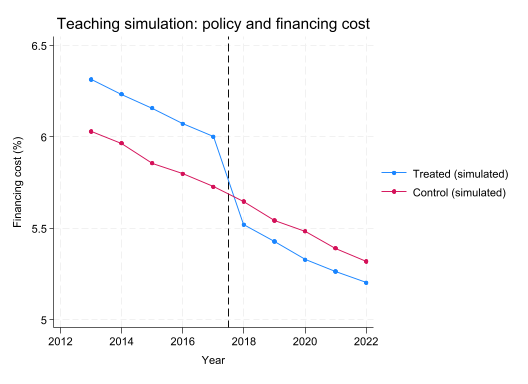

In [4]:
preserve
collapse (mean) cost, by(treat year)
export delimited using "data/intro/policy-means.csv", replace
local stamp : display %tcCCYYNNDD_HHMMSS clock("`c(current_date)' `c(current_time)'", "DMY hms")
local stamp = subinstr("`stamp'", " ", "-", .)
twoway (connected cost year if treat==1) ///
    (connected cost year if treat==0), ///
    xline(2017.5, lpattern(dash)) ///
    legend(order(1 "Treated (simulated)" 2 "Control (simulated)")) ///
    ytitle("Financing cost (%)") xtitle("Year") ///
    title("Teaching simulation: policy and financing cost")
graph export "figs/raw/fineco-intro-fig04-policy-`stamp'.png", ///
    width(1600) replace
restore

## 4. 改变假设，观察结果

先做一个容易理解的改动：保持城市、企业、年份、噪声和随机种子不变，只把写入的政策效应减小。这样可以检查自己是否理解系数单位与数据生成机制。

::: {.callout-tip title="课后小实验：只改已知效应"}

1. 在独立练习项目中，把生成 `cost` 那一行的 `-0.4*did` 改为 `-0.2*did`。
2. 将结果提示文字 `Known simulated effect` 和相关说明同步改为 -0.2，避免旧标签误导读者；不改变其他生成参数和随机种子。
3. 先预测手算和固定效应系数的变化，再重启内核从头运行。
4. 比较新的估计与 -0.2 的差距，解释为什么它不必恰好等于 -0.2。

:::

进阶时再研究识别条件：让处理组从 2013 年开始、在整个观测期持续拥有一条额外趋势，保持已知政策效应不变，观察原 DID 会不会将趋势差异混入政策系数。此时已经改变反事实变化规律，需要重新讨论平行趋势，不应只追求显著性。

真实政策研究还要核查试点边界、政策年过渡、迁址、其他政策、跨地区溢出，以及谁的融资成本能被观察。模拟帮助我们理解怎样比较；这些制度与数据问题决定真实比较是否可信。

[返回练习路线](../../getting-started.qmd#sec-guide-practice) · [提交一页研究计划](../../exercises/research-plan.qmd)